In [2]:
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor


In [3]:
#carica il dataset
data = fetch_california_housing(as_frame=True)
df = data.frame


In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
numeri = df.select_dtypes(include=np.number) #prendo solo le colonne numeriche
columns = numeri.columns



quartili a 25 e 75

In [6]:
#quartili
Q1 = numeri.quantile(0.20)
Q3 = numeri.quantile(0.70)
IQR = Q3 - Q1
df_clean= numeri[~((numeri < (Q1 - 1.5 * IQR)) |(numeri > (Q3 + 1.5 * IQR))).any(axis=1)]


In [7]:
#Split iniziale

x = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Train Set: {X_train.shape}, Test Set: {X_test.shape}")


Train Set: (16512, 8), Test Set: (4128, 8)


In [8]:
#Feature Engineering
#vogliamo catturare le curve, solo rette
# include_bias=False perchè l'intercetta è già inclusa nel modello
from sklearn.preprocessing import PolynomialFeatures
print("\n-----Espansione polinomiale-----")

poly = PolynomialFeatures(degree=2, include_bias=False)
#fill solo per il train
X_train_poly = poly.fit_transform(X_train)

#transform anche per il test
X_test_poly = poly.transform(X_test)

print(f"Nuove dimensioni del train set: {X_train_poly.shape}")


-----Espansione polinomiale-----
Nuove dimensioni del train set: (16512, 44)


In [9]:
#Fase 3: scaling (standardizzazione)
#fondamentale per ridge: se abbiamo x e x^2, x^2 sarà enorme.
print("\n-----Standardizzazione-----")
scaler = StandardScaler()

#fit solo su train (calcola media e deviazione standard)
X_train_scaled = scaler.fit_transform(X_train_poly)

#transform su test 
#se facessimo fit sul test, sarebbe data leakage
X_test_scaled = scaler.transform(X_test_poly)
print("Standardizzazione completata.")


-----Standardizzazione-----
Standardizzazione completata.


In [10]:
#Modellazione con Ridge Regression e Confronto lineare
print("\n-----Addestramento Modelli-----")

#Modello A: Regressione Lineare
from sklearn.linear_model import Ridge, LinearRegression, Lasso
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
y_pred_linear = model_linear.predict(X_test_scaled)

#Modello B: Ridge Regression
model_ridge = Lasso(alpha=0.02)

model_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = model_ridge.predict(X_test_scaled)



-----Addestramento Modelli-----


c:\Users\compu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.275e+00, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


In [11]:
#Fase 5: valutazione e confronto
from sklearn.metrics import mean_squared_error, r2_score
print("\n-----Risultati sul Test Set-----")

#metriche modello lineare
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)
print(f"Modello Lineare - RMSE: {rmse_linear:.4f}, R2: {r2_linear:.4f}")

#metriche modello ridge
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge Regression - RMSE: {rmse_ridge:.4f}, R2: {r2_ridge:.4f}")

#calcolo il miglioramento 
improvement = (rmse_linear - rmse_ridge) / rmse_linear * 100
print(f"Miglioramento RMSE con Ridge: {improvement:.2f}%")


-----Risultati sul Test Set-----
Modello Lineare - RMSE: 0.6814, R2: 0.6457
Ridge Regression - RMSE: 0.7541, R2: 0.5660
Miglioramento RMSE con Ridge: -10.68%


In [12]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

model_elastic = ElasticNet(alpha=0.02, l1_ratio=0.5)
model_elastic.fit(X_train_scaled, y_train)
y_pred = model_elastic.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print ("MSE:", mse)
print ("R2:", r2)

MSE: 0.568761107613964
R2: 0.5659667195065528


In [13]:
# creazione della nuova feature
df['BedroomsRatio'] = df['AveBedrms'] / (df['AveRooms'] + 1e-6)

# selezione delle feature X 
X = df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'BedroomsRatio']]
y = df['MedHouseVal']

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train Set: {X_train.shape}, Test Set: {X_test.shape}")

#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#modello lasso
model_lasso = Lasso(alpha=0.02)
model_lasso.fit(X_train_scaled, y_train)

# predizioni e metriche
y_pred_lasso = model_lasso.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


Train Set: (16512, 9), Test Set: (4128, 9)
MSE: 0.568761107613964
R2: 0.5659667195065528


In [14]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#alleniamo modello ridge
model_lasso = Ridge(alpha=0.02)
model_lasso.fit(X_train_scaled, y_train)

#predizione
y_pred = model_lasso.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)




MSE: 0.5558908615364845
R2: 0.5757882685734377


In [15]:
#xgboost regressor
#oulier removal con IQR
def remove_outliers_iqr(X, y):
    mask = pd.Series(True, index=X.index)
    
    for col in X.columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        col_mask = ~((X[col] < (Q1 - 1.5 * IQR)) | (X[col] > (Q3 + 1.5 * IQR)))
        mask &= col_mask
    return X[mask], y[mask]

X_train_clean, y_train_clean = remove_outliers_iqr(x, y)
print(f"Train Set after outlier removal: {X_train_clean.shape}")


Train Set after outlier removal: (16842, 8)


In [16]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_clean, y_train_clean)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
#valutazione senza outlier removal

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.3950354730305965
R2: 0.8809127321746577


In [18]:
#confronto senza outlier removal

model_raw = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_raw.fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)
rmse_raw = np.sqrt(mean_squared_error(y_test, y_pred_raw))
r2_raw = r2_score(y_test, y_pred_raw)
print("Senza Outlier Removal - RMSE:", rmse_raw)
print("Senza Outlier Removal - R2:", r2_raw)


Senza Outlier Removal - RMSE: 0.4549525711763628
Senza Outlier Removal - R2: 0.8420479060683504


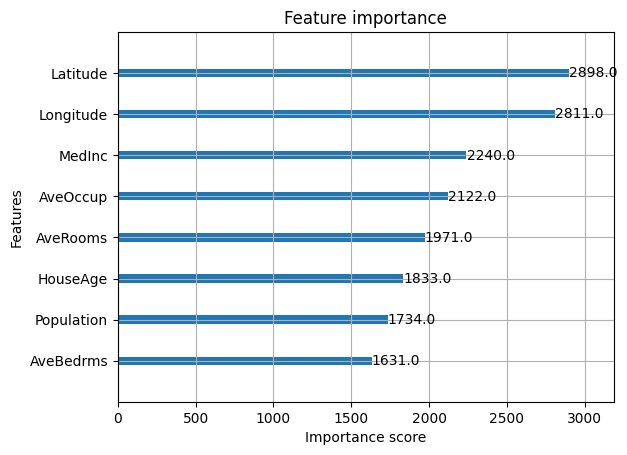

In [19]:
#feature importance

from xgboost import plot_importance

plot_importance(model, max_num_features=10)
plt.show()


In [20]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }
    
    model = XGBRegressor(**param)
    scores = cross_val_score(
        model, 
        X_train_clean, 
        y_train_clean, 
        cv=3, 
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()

# ottimizzazione con Optuna

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Migliori parametri:")
print(study.best_params)
print("Miglior RMSE CV:", study.best_value)


c:\Users\compu\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-09 12:40:11,404] A new study created in memory with name: no-name-8fcf0011-e607-4c83-810f-f83df67283b3
[I 2025-12-09 12:40:17,709] Trial 0 finished with value: 0.4404592810432632 and parameters: {'n_estimators': 347, 'max_depth': 7, 'learning_rate': 0.06884507894350597, 'subsample': 0.8297054550931816, 'colsample_bytree': 0.8736433035141281, 'min_child_weight': 6, 'reg_alpha': 0.7138627804545193, 'reg_lambda': 9.662381884436973}. Best is trial 0 with value: 0.4404592810432632.
[I 2025-12-09 12:40:22,686] Trial 1 finished with value: 0.4491516677019334 and parameters: {'n_estimators': 732, 'max_depth': 4, 'learning_rate': 0.017754020869457515, 'subsample': 0.9496897044448346, 'colsample_bytree': 0.71053

Migliori parametri:
{'n_estimators': 465, 'max_depth': 8, 'learning_rate': 0.02011370708360487, 'subsample': 0.7324067824969658, 'colsample_bytree': 0.9196415506014141, 'min_child_weight': 5, 'reg_alpha': 0.30790498248154863, 'reg_lambda': 8.943474006973217}
Miglior RMSE CV: 0.42166910043129663


In [21]:
#modello finale con parametri ottimizzati

best_model = XGBRegressor(
    **study.best_params,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_clean, y_train_clean)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9196415506014141
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
#valutazione test

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE Test:", rmse)
print("R2 Test:", r2)

RMSE Test: 0.38561166860262164
R2 Test: 0.8865267550577157


codice delle slides un po' ottimizzato

--- 1. Caricamento Dati ---
Train shape: (16512, 8) (Dati usati per Optuna e Training)
Test shape:  (4128, 8) (Dati nascosti fino alla fine)

--- Calcolo Baseline (Modello Standard) ---
RMSE Baseline: 0.4718

--- Inizio Tuning Iperparametri ---

Migliori parametri trovati: {'max_depth': 9, 'min_child_weight': 11, 'learning_rate': 0.03366440018385843, 'subsample': 0.6505690597794851, 'colsample_bytree': 0.6897979775731335, 'gamma': 0.0011888670833573025, 'alpha': 0.00308416820395238, 'lambda': 1.3242692562789522e-07}

--- 3. Training Modello Finale (con Shrinkage) ---
-> Learning Rate ridotto a: 0.01683
-> Boost Rounds aumentati a: 1240

--- RISULTATI FINALI SUL TEST SET ---
RMSE Finale: 0.4339
R2 Score:    0.8563
Miglioramento vs Baseline: 0.0379 (RMSE più basso è meglio)

Generazione grafico importanza feature...


<Figure size 1000x600 with 0 Axes>

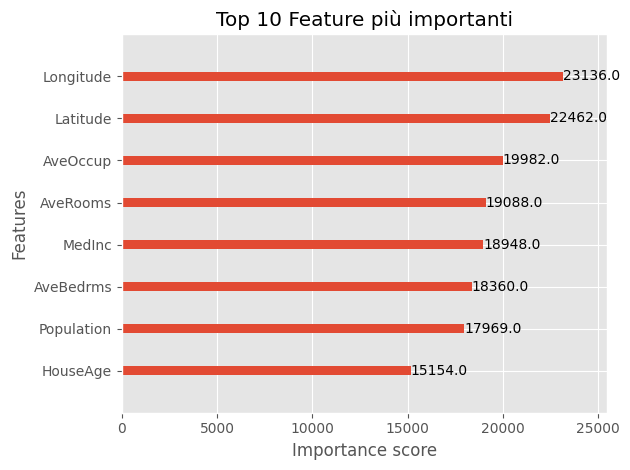

In [23]:
import optuna
import xgboost as xgb
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Importazioni per metriche e gestione dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score

# --- CONFIGURAZIONE INIZIALE ---
# Riduciamo il rumore nei log di Optuna (mostra solo errori/warning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
# Ignoriamo warning di versione o deprecazione per pulizia output
warnings.filterwarnings('ignore')
# Stile grafico per i plot (più gradevole del default)
plt.style.use('ggplot')

# ==========================================
# 1. FUNZIONI DI GESTIONE DATI
# ==========================================

def load_and_split_data():
    """
    Carica il dataset e divide in Train/Test set.
    Converte in Pandas DataFrame per avere i nomi delle colonne nei grafici.
    """
    print("--- 1. Caricamento Dati ---")
    data = fetch_california_housing()
    
    # Creiamo DataFrame Pandas (X) e Series (y).
    # È utile perché XGBoost userà i nomi delle colonne (es. 'MedInc') nei grafici di importanza.
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.Series(data.target, name="Target")
    
    # Split: 80% Training, 20% Test.
    # Il Test Set viene "congelato" e usato SOLO alla fine assoluta per valutare la performance reale.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42 # Random state fisso per riproducibilità
    )
    
    print(f"Train shape: {X_train.shape} (Dati usati per Optuna e Training)")
    print(f"Test shape:  {X_test.shape} (Dati nascosti fino alla fine)")
    return X_train, X_test, y_train, y_test

def get_base_params():
    """
    Restituisce i parametri fissi di base che non ottimizziamo.
    """
    return {
        'objective': 'reg:squarederror', # Funzione di perdita per regressione (minimi quadrati)
        'eval_metric': 'rmse',           # Metrica di valutazione
        'tree_method': 'hist',           # Metodo 'histogram': molto più veloce su grandi dati
        'nthread': -1,                   # Usa tutti i core della CPU disponibili
        'verbosity': 0                   # Silenzioso
    }

# ==========================================
# 2. CUORE DELL'OTTIMIZZAZIONE (OPTUNA)
# ==========================================

def objective(trial, X, y):
    """
    Funzione obiettivo che Optuna cercherà di minimizzare.
    Usa Cross-Validation (CV) invece di un semplice split per essere più robusto.
    """
    
    # --- A. Definizione Spazio di Ricerca (Iperparametri) ---
    params = get_base_params()
    
    # .suggest_int/float: Optuna sceglie un valore in questo range
    params.update({
        # Profondità dell'albero: controlla la complessità (troppo alto = overfitting)
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        
        # Peso minimo in una foglia: previene che l'albero impari casi troppo specifici (rumore)
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        
        # Learning Rate: velocità di apprendimento. 
        # log=True significa che esploriamo ordini di grandezza (es. 0.01 è diverso da 0.1)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        
        # Percentuale di righe (subsample) e colonne (colsample) usate per ogni albero.
        # Aggiunge casualità rendendo il modello più robusto.
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        
        # Parametri di regolarizzazione (Gamma, Alpha L1, Lambda L2)
        # Servono a penalizzare modelli troppo complessi.
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
    })

    # --- B. Cross-Validation (CV) ---
    # Convertiamo i dati nel formato ottimizzato di XGBoost
    dtrain = xgb.DMatrix(X, label=y)
    
    # Eseguiamo la CV. 'nfold=3' divide i dati in 3 parti. 
    # Il modello si allena su 2 e testa su 1, ripetendo il giro 3 volte.
    # Questo ci dà un RMSE medio molto affidabile, non dipendente dalla fortuna.
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=1000,    # Numero massimo di alberi
        nfold=3,                 # Numero di pieghe (folds)
        stratified=False,        # False per regressione (True si usa per classificazione)
        early_stopping_rounds=50,# Si ferma se l'errore non scende per 50 round
        metrics="rmse",          # Metrica da monitorare
        seed=42,
        verbose_eval=False
    )
    
    # --- C. Risultato ---
    # Prendiamo l'ultimo valore medio di RMSE (il migliore raggiunto prima dello stop)
    best_rmse = cv_results['test-rmse-mean'].min()
    
    # SALVATAGGIO SPECIALE:
    # Salviamo quanti alberi (rounds) sono serviti per ottenere questo risultato.
    # Ci servirà dopo per allenare il modello finale senza dover indovinare.
    trial.set_user_attr("n_estimators", len(cv_results))
    
    return best_rmse

# ==========================================
# 3. TRAINING FINALE E METRICHE
# ==========================================

def train_final_model(best_params, n_estimators, X_train, y_train):
    """
    Allena il modello definitivo usando tutti i dati di train disponibili.
    Applica la strategia 'Shrinkage' (Learning Rate ridotto).
    """
    print("\n--- 3. Training Modello Finale (con Shrinkage) ---")
    
    # --- STRATEGIA SHRINKAGE ---
    # Idea: Optuna ha trovato buoni parametri velocemente.
    # Ora, per la "gara finale", rallentiamo l'apprendimento (LR più basso)
    # e aumentiamo il tempo (più alberi) per ottenere massima precisione.
    shrinkage_factor = 0.5 # Dimezziamo il learning rate
    
    best_params['learning_rate'] = best_params['learning_rate'] * shrinkage_factor
    # Se il LR è metà, servono circa il doppio degli alberi per convergere allo stesso punto
    final_rounds = int(n_estimators / shrinkage_factor)
    
    print(f"-> Learning Rate ridotto a: {best_params['learning_rate']:.5f}")
    print(f"-> Boost Rounds aumentati a: {final_rounds}")

    dtrain = xgb.DMatrix(X_train, label=y_train)
    
    # Training su TUTTO il set di training (nessuna validazione qui, ci fidiamo della CV)
    model = xgb.train(
        best_params,
        dtrain,
        num_boost_round=final_rounds
    )
    return model

def evaluate_model(model, X_test, y_test, baseline_rmse=None):
    """
    Test finale sui dati mai visti (Test Set).
    """
    dtest = xgb.DMatrix(X_test, label=y_test)
    preds = model.predict(dtest)
    
    # Calcolo metriche
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds) # Quanto "spieghiamo" bene la varianza (1.0 = perfetto)
    
    print("\n--- RISULTATI FINALI SUL TEST SET ---")
    print(f"RMSE Finale: {rmse:.4f}")
    print(f"R2 Score:    {r2:.4f}")
    
    if baseline_rmse:
        imp = baseline_rmse - rmse
        print(f"Miglioramento vs Baseline: {imp:.4f} (RMSE più basso è meglio)")
        
    # Grafico Importanza Feature
    # Mostra quali variabili hanno influenzato di più le decisioni del modello
    print("\nGenerazione grafico importanza feature...")
    plt.figure(figsize=(10, 6))
    xgb.plot_importance(model, max_num_features=10, importance_type='weight', title='Top 10 Feature più importanti')
    plt.tight_layout()
    plt.show()

# ==========================================
# MAIN EXECUTION (FLUSSO PRINCIPALE)
# ==========================================

if __name__ == "__main__":
    # 1. Carichiamo i dati
    X_train, X_test, y_train, y_test = load_and_split_data()

    # 2. Calcoliamo una Baseline veloce (senza tuning) per avere un confronto
    print("\n--- Calcolo Baseline (Modello Standard) ---")
    base_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    base_model.fit(X_train, y_train)
    base_preds = base_model.predict(X_test)
    rmse_base = np.sqrt(mean_squared_error(y_test, base_preds))
    print(f"RMSE Baseline: {rmse_base:.4f}")

    # 3. Avviamo Optuna
    print("\n--- Inizio Tuning Iperparametri ---")
    study = optuna.create_study(direction='minimize') # Vogliamo minimizzare l'RMSE
    
    # Usiamo una lambda function per passare i dati (X_train, y_train) alla funzione objective
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30, timeout=600)

    print("\nMigliori parametri trovati:", study.best_params)
    
    # 4. Prepariamo i parametri per il training finale
    final_params = get_base_params()
    final_params.update(study.best_params) # Uniamo parametri fissi + parametri ottimizzati
    
    # Recuperiamo il numero "magico" di stimatori trovato dalla CV nel trial migliore
    best_n_estimators = study.best_trial.user_attrs["n_estimators"]
    
    # 5. Alleniamo il modello definitivo (Best Params + Shrinkage)
    model_opt = train_final_model(final_params, best_n_estimators, X_train, y_train)
    
    # 6. Valutazione Finale (La prova del nove)
    evaluate_model(model_opt, X_test, y_test, baseline_rmse=rmse_base)